### STEP 5.1 网格搜索主模型最佳超参数

In [ ]:
import os
import copy
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import itertools
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 全局配置与路径
# ==========================================
DEBUG_MODE = False  # 正式网格搜索请保持 False
DATA_PATH = '../data/03_final_feature_matrix.csv'
MODEL_DIR = '../models/grid_search_main/'
RESULT_DIR = '../results/'
LOG_FILE = os.path.join(RESULT_DIR, 'grid_search_results_attention.csv')

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 2. 网格搜索空间定义 (Grid Search Space)
# ==========================================
param_grid = {
    'hidden_size': [64, 128],   # Bi-LSTM单向维度，拼接后全连接层输入为128或256
    'dropout': [0.3, 0.5],
    'batch_size': [32, 64],
    'lr': [0.001, 0.0005],
    'feature_group': ['G1', 'G2', 'G3', 'G3-M']
}

# 冒烟测试模式下的极小搜索空间
if DEBUG_MODE:
    param_grid = {
        'hidden_size': [64],
        'dropout': [0.3],
        'batch_size': [32],
        'lr': [0.001],
        'feature_group': ['G1']
    }

# ==========================================
# 3. 数据集与模型定义 (Bi-LSTM + Attention)
# ==========================================
class CryptoVolatilityDataset(Dataset):
    def __init__(self, feature_matrix, target_array, lookback_window=7):
        self.features = feature_matrix
        self.targets = target_array
        self.window = lookback_window
        
    def __len__(self):
        return len(self.features) - self.window + 1
        
    def __getitem__(self, idx):
        x = self.features[idx : idx + self.window]
        y = self.targets[idx + self.window - 1]
        return torch.FloatTensor(x), torch.FloatTensor([y])


class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionLayer, self).__init__()
        self.attention_weights = nn.Linear(hidden_dim, 1, bias=False)
        
    def forward(self, lstm_output):
        # lstm_output: (Batch, Seq_Len, hidden_dim)
        scores = self.attention_weights(lstm_output)
        alpha = F.softmax(scores, dim=1)
        context_vector = torch.sum(alpha * lstm_output, dim=1)
        return context_vector, alpha.squeeze(-1)


class BiLSTMAttention(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p):
        super(BiLSTMAttention, self).__init__()
        # 双向LSTM，输出维度将会是 hidden_size * 2
        self.bilstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=1, 
            batch_first=True,
            bidirectional=True
        )
        
        lstm_out_dim = hidden_size * 2
        
        self.attention = AttentionLayer(hidden_dim=lstm_out_dim)
        self.dropout = nn.Dropout(p=dropout_p)
        
        self.fc_layers = nn.Sequential(
            nn.Linear(lstm_out_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        lstm_out, _ = self.bilstm(x)
        context, attn_weights = self.attention(lstm_out)
        dropped_out = self.dropout(context)
        out = self.fc_layers(dropped_out)
        return out, attn_weights

# ==========================================
# 4. 核心训练函数 (含防御机制)
# ==========================================
def train_and_validate(model, train_loader, val_loader, params, config_str):
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6)
    
    best_val_loss = float('inf')
    best_model_wts = None
    patience, epochs_no_improve = 15, 0
    max_epochs = 5 if DEBUG_MODE else 200
    
    for epoch in range(max_epochs):
        # --- 训练阶段 ---
        model.train()
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds, _ = model(x_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            
        # --- 验证阶段 ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_v, y_v in val_loader:
                x_v, y_v = x_v.to(device), y_v.to(device)
                preds, _ = model(x_v)
                val_losses.append(criterion(preds, y_v).item())
        
        avg_val_loss = np.mean(val_losses)
        scheduler.step(avg_val_loss)
        
        # --- Early Stopping ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= patience:
            break
            
    # 恢复最佳权重
    model.load_state_dict(best_model_wts)
    return model, best_val_loss

# ==========================================
# 5. 网格搜索主逻辑
# ==========================================
def run_grid_search():
    df = pd.read_csv(DATA_PATH)
    all_cols = list(df.columns)
    base_features = [c for c in all_cols if c not in ['timestamp', 'target_sigma_t_plus_1', 'finbert_sentiment_score', 'llm_composite_score', 'sentiment_class', 'action_class', 'action_score']]
    
    # 特征组映射
    fg_map = {
        'G1': base_features,
        'G2': base_features + ['finbert_sentiment_score'],
        'G3': base_features + ['llm_composite_score'],
        'G3-M': base_features + ['sentiment_class', 'action_class', 'action_score']
    }

    # 生成所有参数组合
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    print(f"开始主模型(Bi-LSTM+Attn)网格搜索，共计 {len(combinations)} 组实验...")

    for i, params in enumerate(combinations):
        config_id = f"BiLSTMAttn_{params['feature_group']}_h{params['hidden_size']}_dp{params['dropout']}_bs{params['batch_size']}_lr{params['lr']}"
        print(f"[{i+1}/{len(combinations)}] 正在训练: {config_id}")
        
        # 1. 准备数据
        f_cols = fg_map[params['feature_group']]
        train_end, val_end = int(len(df)*0.7), int(len(df)*0.8)
        
        train_ds = CryptoVolatilityDataset(df.iloc[:train_end][f_cols].values, df.iloc[:train_end]['target_sigma_t_plus_1'].values)
        val_ds = CryptoVolatilityDataset(df.iloc[train_end:val_end][f_cols].values, df.iloc[train_end:val_end]['target_sigma_t_plus_1'].values)
        test_ds = CryptoVolatilityDataset(df.iloc[val_end:][f_cols].values, df.iloc[val_end:]['target_sigma_t_plus_1'].values)
        
        train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=params['batch_size'], shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=params['batch_size'], shuffle=False)
        
        # 2. 训练与早停
        torch.cuda.empty_cache()  # 严格显存回收
        model = BiLSTMAttention(len(f_cols), params['hidden_size'], params['dropout']).to(device)
        model, _ = train_and_validate(model, train_loader, val_loader, params, config_id)
        
        # 3. 测试集评估 (评估时同样需要拆包preds, attn_weights)
        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for x_t, y_t in test_loader:
                batch_preds, _ = model(x_t.to(device))
                preds.extend(batch_preds.cpu().numpy())
                targets.extend(y_t.numpy())
        
        preds, targets = np.array(preds).flatten(), np.array(targets).flatten()
        rmse = np.sqrt(mean_squared_error(targets, preds))
        mae = mean_absolute_error(targets, preds)
        r2 = r2_score(targets, preds)
        
        # 4. 记录结果与保存模型
        result_entry = {
            'Model': 'Bi-LSTM+Attention',
            **params, 
            'RMSE': rmse, 
            'MAE': mae, 
            'R2': r2, 
            'Timestamp': time.strftime("%Y-%m-%d %H:%M:%S")
        }
        res_df = pd.DataFrame([result_entry])
        res_df.to_csv(LOG_FILE, mode='a', header=not os.path.exists(LOG_FILE), index=False)
        
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, f"best_{config_id}.pth"))

if __name__ == '__main__':
    run_grid_search()

### step 5.2 以最佳参数训练主模型并生成可视化结果

>>> 环境初始化中，检查 GPU 状态...
>>> 当前使用的计算设备: cuda
>>> 正在加载数据...

开始生成第五章 主模型(Bi-LSTM+Attn) 正式结果

[任务启动] 正在处理 G1 组 (参数: {'hidden_size': 128, 'dropout': 0.3, 'batch_size': 64, 'lr': 0.001})
    -> 数据集构建完成，准备清空显存并训练...
    -> [G1] 触发早停，最佳 Epoch 停留在 10
    -> 训练完成，正在对测试集进行推理与 Attention 权重提取...
    -> 数据成功落盘！预测结果: ../results/attn_pred_G1.csv | Attention权重: ../results/attn_weights_G1.npy

[任务启动] 正在处理 G2 组 (参数: {'hidden_size': 64, 'dropout': 0.5, 'batch_size': 64, 'lr': 0.0005})
    -> 数据集构建完成，准备清空显存并训练...
    -> [G2] 触发早停，最佳 Epoch 停留在 12
    -> 训练完成，正在对测试集进行推理与 Attention 权重提取...
    -> 数据成功落盘！预测结果: ../results/attn_pred_G2.csv | Attention权重: ../results/attn_weights_G2.npy

[任务启动] 正在处理 G3 组 (参数: {'hidden_size': 128, 'dropout': 0.3, 'batch_size': 64, 'lr': 0.001})
    -> 数据集构建完成，准备清空显存并训练...
    -> [G3] 触发早停，最佳 Epoch 停留在 29
    -> 训练完成，正在对测试集进行推理与 Attention 权重提取...
    -> 数据成功落盘！预测结果: ../results/attn_pred_G3.csv | Attention权重: ../results/attn_weights_G3.npy

[任务启动] 正在处理 G3-M 组 (参数: {'hidden_size': 12

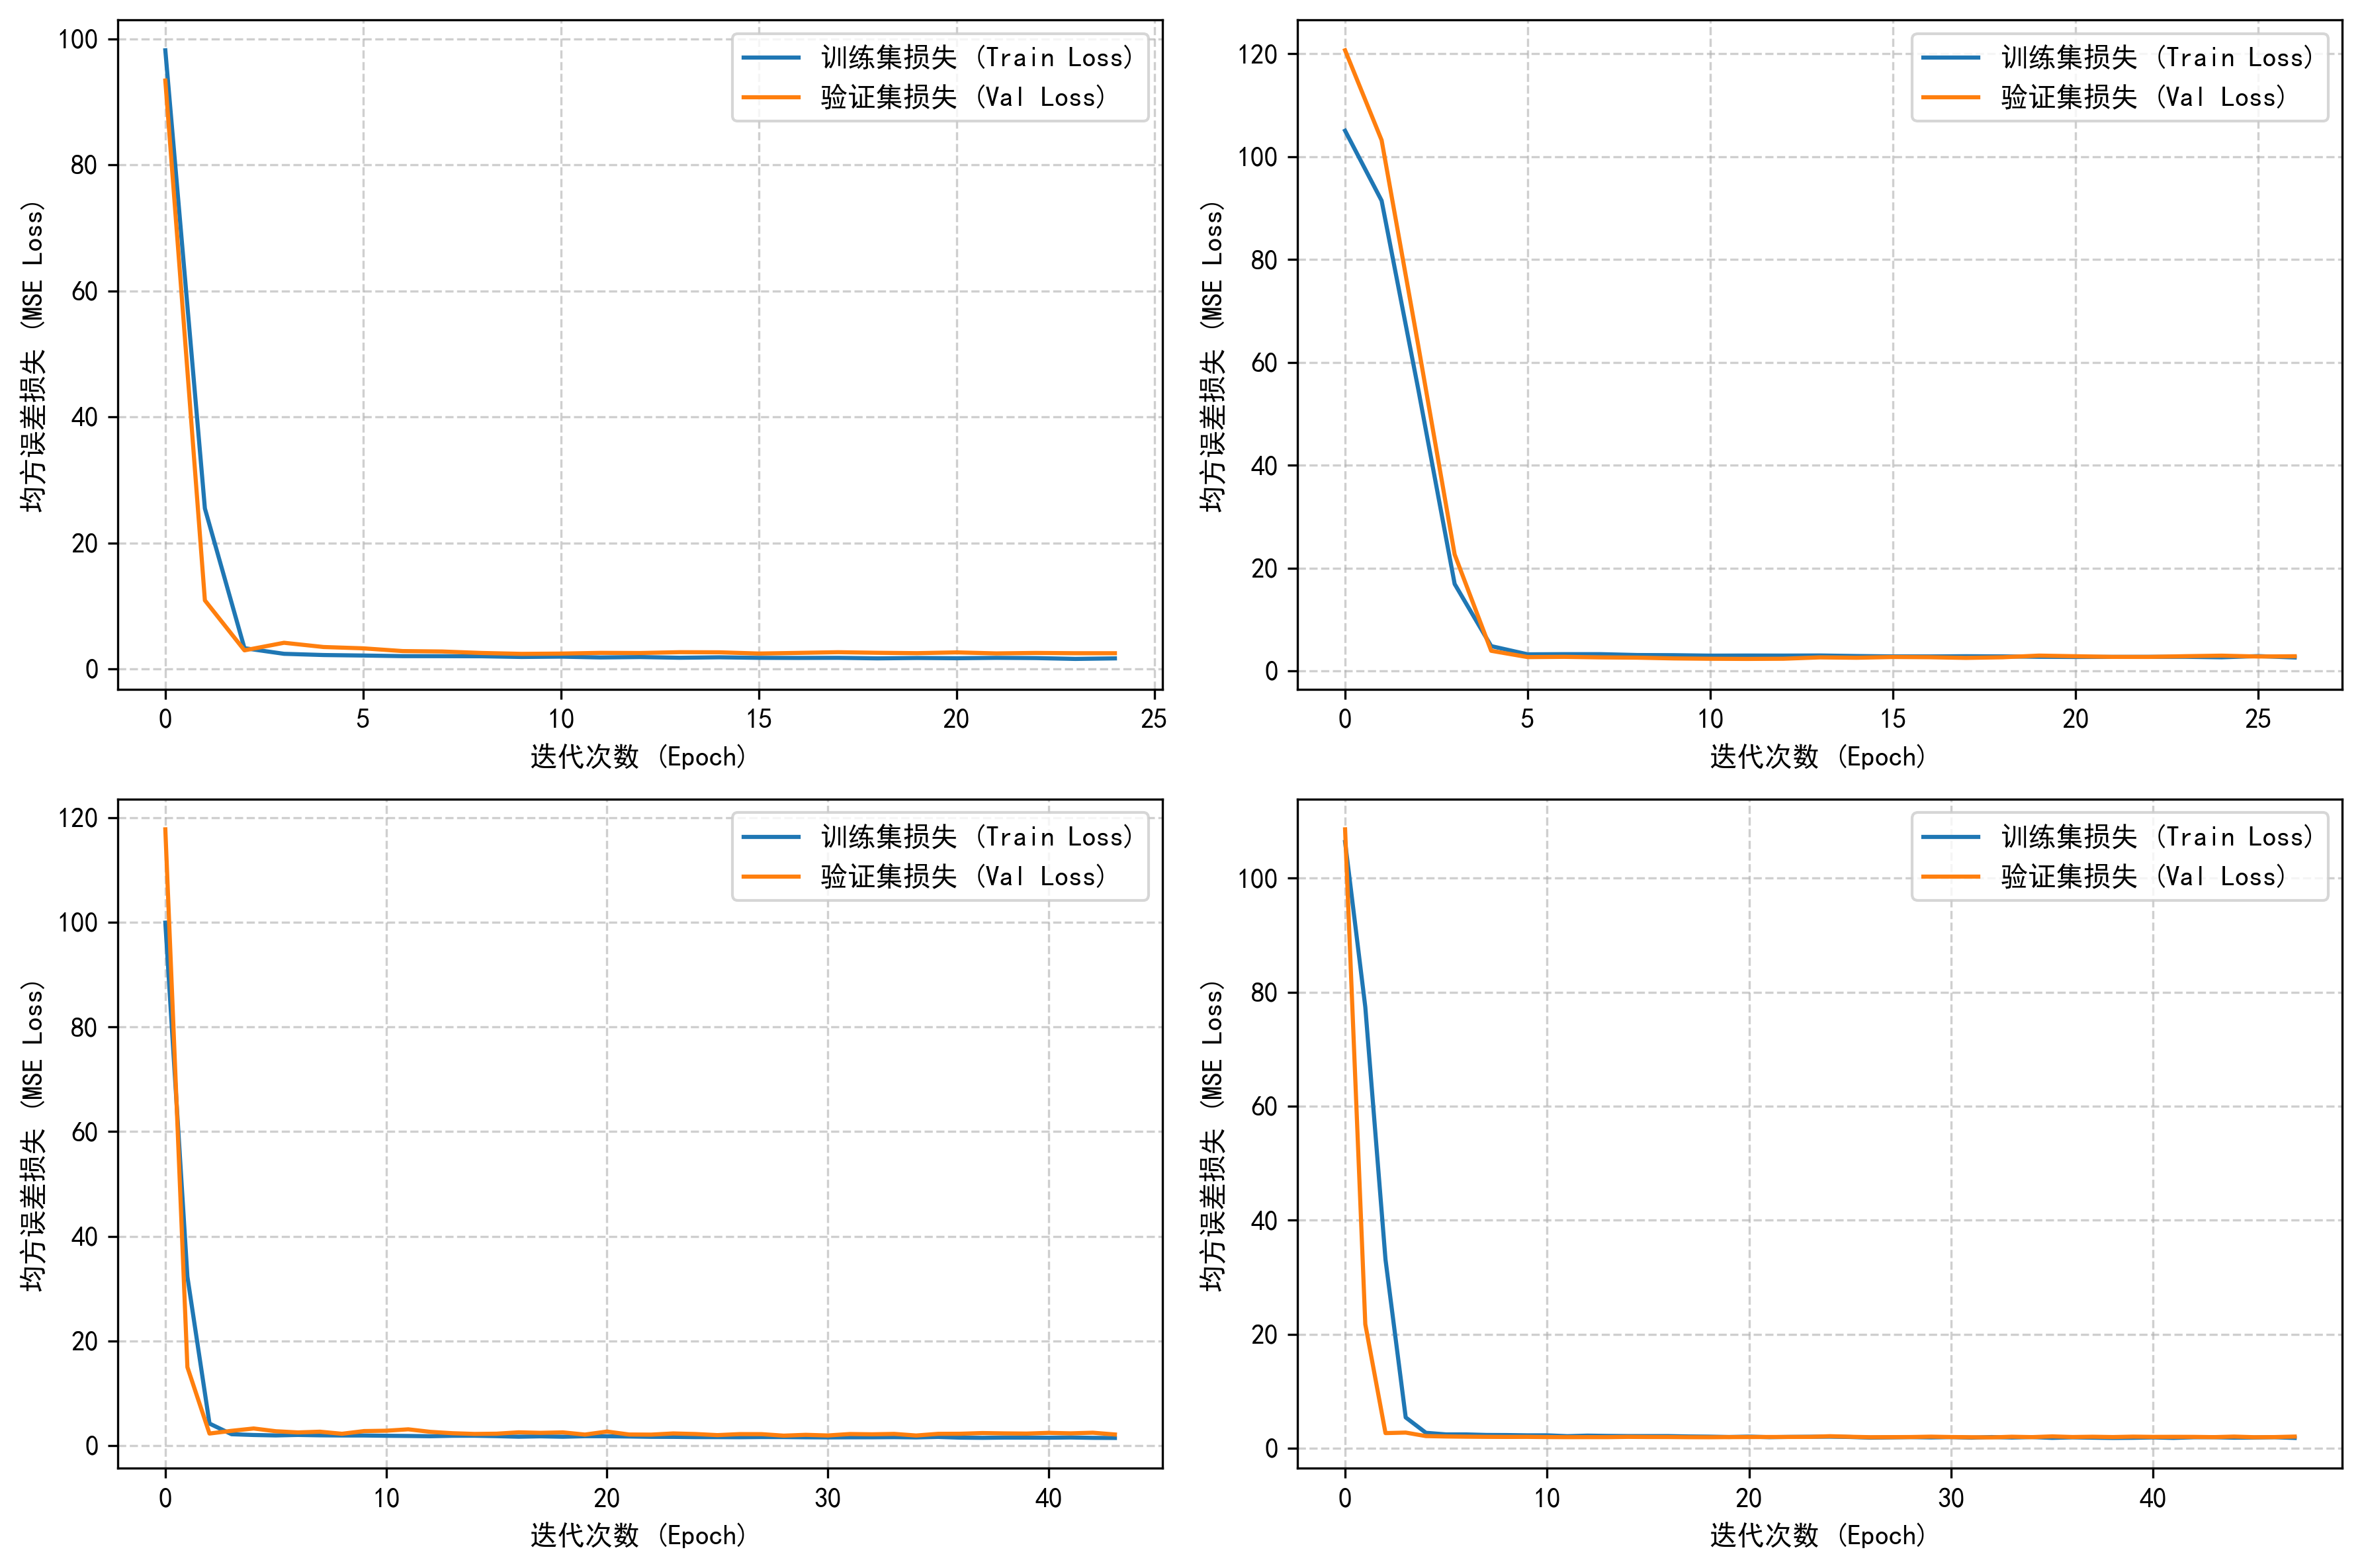

>>> 任务全部完成！图表已保存至: ../results/5_2_attn_loss.png


In [1]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

print(">>> 环境初始化中，检查 GPU 状态...")

# ==========================================
# 0. 绘图规范与中文字体设置 (Windows 兼容)
# ==========================================
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置黑体，用于正常显示中文
plt.rcParams['axes.unicode_minus'] = False    # 修复负号显示问题

# ==========================================
# 1. 全局配置与最佳超参数字典
# ==========================================
DATA_PATH = '../data/03_final_feature_matrix.csv'
MODEL_DIR = '../models/'
RESULT_DIR = '../results/'

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f">>> 当前使用的计算设备: {device}")

# 固化网格搜索得出的主模型最佳参数
best_configs = {
    'G1':   {'hidden_size': 128, 'dropout': 0.3, 'batch_size': 64, 'lr': 0.001},
    'G2':   {'hidden_size': 64,  'dropout': 0.5, 'batch_size': 64, 'lr': 0.0005},
    'G3':   {'hidden_size': 128, 'dropout': 0.3, 'batch_size': 64, 'lr': 0.001},
    'G3-M': {'hidden_size': 128, 'dropout': 0.5, 'batch_size': 64, 'lr': 0.0005}
}

# ==========================================
# 2. 全新的 Dataset 定义 (防污染)
# ==========================================
class CryptoVolatilityDataset(Dataset):
    def __init__(self, feature_matrix, target_array, lookback_window=7):
        self.features = feature_matrix
        self.targets = target_array
        self.window = lookback_window
        
    def __len__(self):
        return len(self.features) - self.window + 1
        
    def __getitem__(self, idx):
        x = self.features[idx : idx + self.window]
        y = self.targets[idx + self.window - 1]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# ==========================================
# 3. 主模型网络结构 (含 Attention 权重提取)
# ==========================================
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionLayer, self).__init__()
        self.attention_weights = nn.Linear(hidden_dim, 1, bias=False)
        
    def forward(self, lstm_output):
        scores = self.attention_weights(lstm_output)
        alpha = F.softmax(scores, dim=1)
        context_vector = torch.sum(alpha * lstm_output, dim=1)
        return context_vector, alpha.squeeze(-1)

class BiLSTMAttention(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p):
        super(BiLSTMAttention, self).__init__()
        self.bilstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=1, 
            batch_first=True,
            bidirectional=True
        )
        lstm_out_dim = hidden_size * 2
        self.attention = AttentionLayer(hidden_dim=lstm_out_dim)
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc_layers = nn.Sequential(
            nn.Linear(lstm_out_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        lstm_out, _ = self.bilstm(x)
        context, attn_weights = self.attention(lstm_out)
        dropped_out = self.dropout(context)
        out = self.fc_layers(dropped_out)
        return out, attn_weights

# ==========================================
# 4. 训练核心函数
# ==========================================
def train_model_for_final_eval(model, train_loader, val_loader, params, group_name):
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6)
    
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    patience, epochs_no_improve = 15, 0
    max_epochs = 200
    
    train_loss_history = []
    val_loss_history = []
    
    model.to(device)
    for epoch in range(max_epochs):
        model.train()
        train_loss = 0.0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds, _ = model(x_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x_batch.size(0)
            
        train_loss /= len(train_loader.dataset)
        train_loss_history.append(train_loss)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_v, y_v in val_loader:
                x_v, y_v = x_v.to(device), y_v.to(device)
                preds, _ = model(x_v)
                loss = criterion(preds, y_v)
                val_loss += loss.item() * x_v.size(0)
                
        val_loss /= len(val_loader.dataset)
        val_loss_history.append(val_loss)
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"    -> [{group_name}] 触发早停，最佳 Epoch 停留在 {epoch+1 - patience}")
                break
                
    model.load_state_dict(best_model_wts)
    save_path = os.path.join(MODEL_DIR, f"attn_final_{group_name}_best.pth")
    torch.save(model.state_dict(), save_path)
    
    return model, train_loss_history, val_loss_history

# ==========================================
# 5. 主流程
# ==========================================
def main():
    print(">>> 正在加载数据...")
    df = pd.read_csv(DATA_PATH)
    all_cols = list(df.columns)
    base_features = [c for c in all_cols if c not in ['timestamp', 'target_sigma_t_plus_1', 'finbert_sentiment_score', 'llm_composite_score', 'sentiment_class', 'action_class', 'action_score']]
    
    fg_map = {
        'G1': base_features,
        'G2': base_features + ['finbert_sentiment_score'],
        'G3': base_features + ['llm_composite_score'],
        'G3-M': base_features + ['sentiment_class', 'action_class', 'action_score']
    }

    train_end = int(len(df) * 0.7)
    val_end = int(len(df) * 0.8)
    
    loss_dict = {}
    
    print("\n==========================================")
    print("开始生成第五章 主模型(Bi-LSTM+Attn) 正式结果")
    print("==========================================")
    
    for group_name, params in best_configs.items():
        print(f"\n[任务启动] 正在处理 {group_name} 组 (参数: {params})")
        f_cols = fg_map[group_name]
        
        train_ds = CryptoVolatilityDataset(df.iloc[:train_end][f_cols].values, df.iloc[:train_end]['target_sigma_t_plus_1'].values)
        val_ds = CryptoVolatilityDataset(df.iloc[train_end:val_end][f_cols].values, df.iloc[train_end:val_end]['target_sigma_t_plus_1'].values)
        test_df = df.iloc[val_end:]
        test_ds = CryptoVolatilityDataset(test_df[f_cols].values, test_df['target_sigma_t_plus_1'].values)
        
        # Windows 安全增强：num_workers=0 且 pin_memory=True
        train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True, num_workers=0, pin_memory=True)
        val_loader = DataLoader(val_ds, batch_size=params['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
        test_loader = DataLoader(test_ds, batch_size=params['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
        
        print(f"    -> 数据集构建完成，准备清空显存并训练...")
        torch.cuda.empty_cache()
        
        model = BiLSTMAttention(input_size=len(f_cols), hidden_size=params['hidden_size'], dropout_p=params['dropout'])
        model, t_loss, v_loss = train_model_for_final_eval(model, train_loader, val_loader, params, group_name)
        
        loss_dict[group_name] = {'train': t_loss, 'val': v_loss}
        
        print(f"    -> 训练完成，正在对测试集进行推理与 Attention 权重提取...")
        model.eval()
        preds, targets, attentions = [], [], []
        with torch.no_grad():
            for x_t, y_t in test_loader:
                batch_preds, batch_attn = model(x_t.to(device))
                preds.extend(batch_preds.cpu().numpy())
                targets.extend(y_t.numpy())
                attentions.append(batch_attn.cpu().numpy())
                
        preds = np.array(preds).flatten()
        targets = np.array(targets).flatten()
        attentions = np.concatenate(attentions, axis=0) 
        
        window = 7
        timestamps = test_df['timestamp'].values[window-1:]
        
        res_df = pd.DataFrame({'timestamp': timestamps, 'true_volatility': targets, 'pred_volatility': preds})
        csv_path = os.path.join(RESULT_DIR, f"attn_pred_{group_name}.csv")
        res_df.to_csv(csv_path, index=False)
        
        npy_path = os.path.join(RESULT_DIR, f"attn_weights_{group_name}.npy")
        np.save(npy_path, attentions)
        
        print(f"    -> 数据成功落盘！预测结果: {csv_path} | Attention权重: {npy_path}")

    print("\n>>> 所有模型运算完毕，开始绘制损失函数折线图...")
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=300)
    axes = axes.flatten()
    
    group_keys = ['G1', 'G2', 'G3', 'G3-M']
    for idx, g in enumerate(group_keys):
        ax = axes[idx]
        ax.plot(loss_dict[g]['train'], label='训练集损失 (Train Loss)', color='#1f77b4', linewidth=1.5)
        ax.plot(loss_dict[g]['val'], label='验证集损失 (Val Loss)', color='#ff7f0e', linewidth=1.5)
        ax.set_xlabel('迭代次数 (Epoch)')
        ax.set_ylabel('均方误差损失 (MSE Loss)')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
        
    plt.tight_layout()
    fig_save_path = os.path.join(RESULT_DIR, "5_2_attn_loss.png")
    plt.savefig(fig_save_path, format='png', bbox_inches='tight')
    plt.show()
    print(f">>> 任务全部完成！图表已保存至: {fig_save_path}")

if __name__ == '__main__':
    main()